In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['pdf.fonttype'] = 42
mpl.rcParams['ps.fonttype'] = 42

In [7]:
df_massql = pd.read_csv("carnitines_massql_library.tsv", sep="\t")
df_reported = pd.read_csv("reported_carnitines_updated_03_05_2026.tsv", sep="\t")

In [3]:
df_massql.head()

,precmz_massql,delta_mass_r2_massql,mass_defect_massql
0,144.07001,-18.04,-0.000278
1,144.10001,-18.01,-0.000069
2,145.04897,-17.06,-0.000414
3,146.11774,-15.99,0.000068
4,153.10712,-9.01,-0.000065


In [8]:
df_reported

,formula_reported,exact_mass_reported,delta_mass_r2_reported,source_reported,mass_defect_reported
0,C6H17N,103.136100,-58.98,chebi,0.000194
1,C6H17N,103.136100,-58.97,chebi,0.000291
2,C7H16NO2,146.118100,-16.00,zhang,0.000000
3,C7H16NO2,146.118100,-15.99,zhang,0.000068
4,C7H14NO3,160.097370,-2.02,"hmdb, zhang",-0.000125
...,...,...,...,...,...
824,C31H56NO13,650.375170,488.25,"stein, zhang",0.000384
825,C31H56NO13,650.375170,488.28,"stein, zhang",0.000431
826,DC8:0 acylcarnitine,318.191114,156.08,emily,0.000251
827,C21:0-21OH acylcarnitine,486.415300,324.31,emily,0.000637


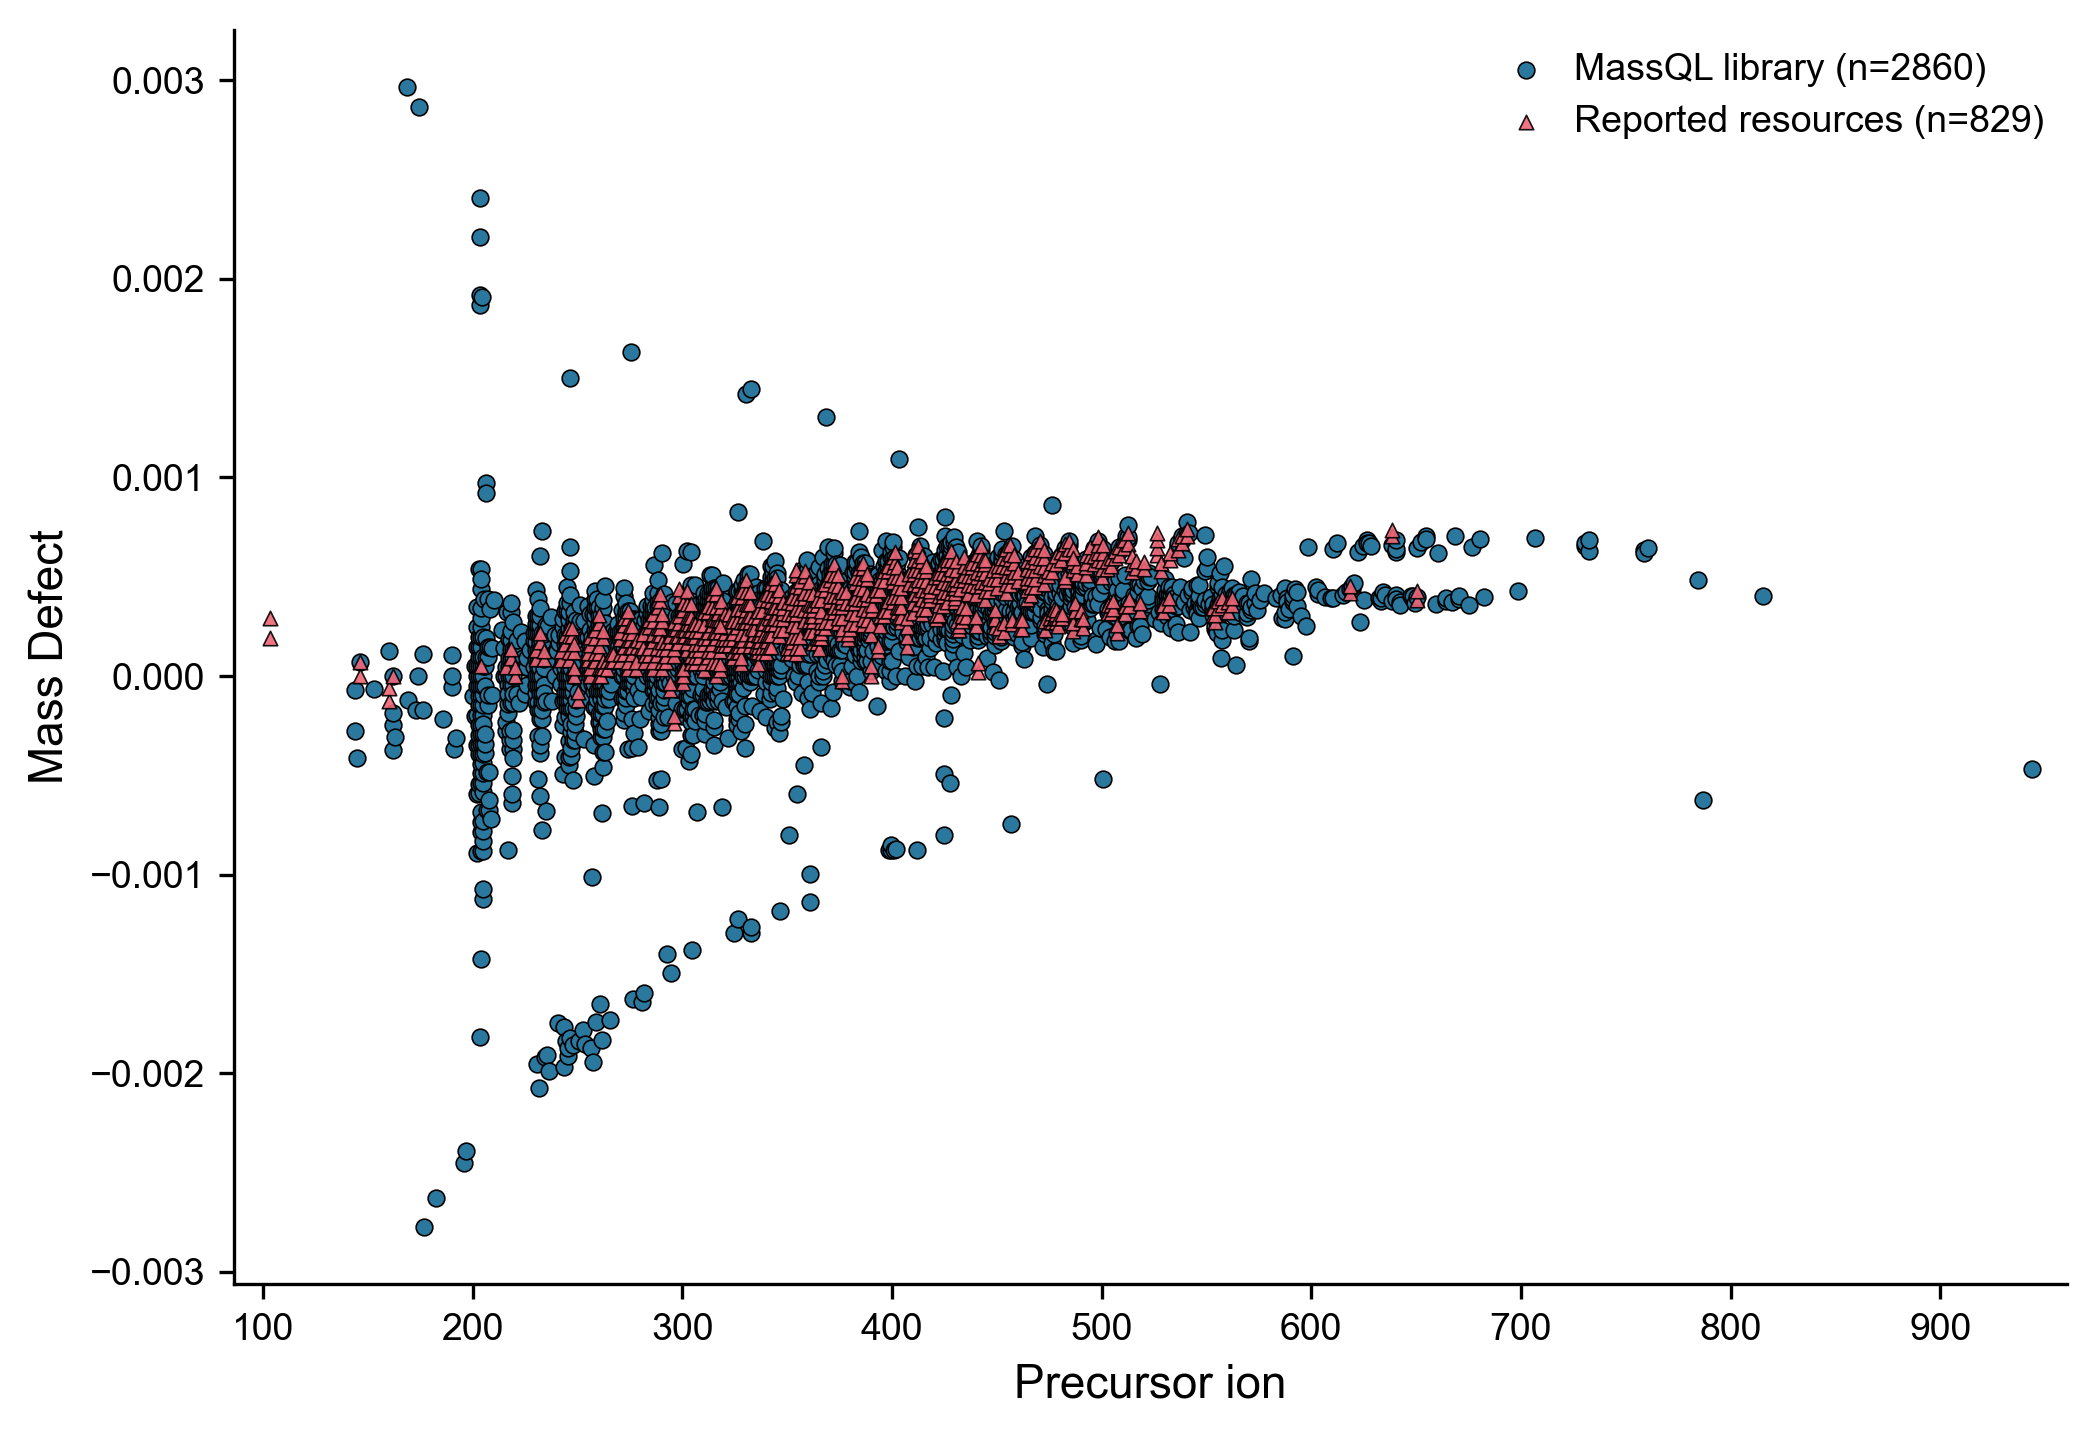

In [20]:
# --- prepare data and counts (unique deltas) ---
mql = df_massql[['precmz_massql', 'mass_defect_massql', 'delta_mass_r2_massql']].dropna()
rep = df_reported[['exact_mass_reported', 'mass_defect_reported', 'delta_mass_r2_reported']].dropna()

n_mql = mql['delta_mass_r2_massql'].nunique()
n_rep = rep['delta_mass_r2_reported'].nunique()

label_mql = f"MassQL library (n={n_mql})"
label_rep = f"Reported resources (n={n_rep})"

# --- palette (Okabe–Ito, colorblind-safe) ---
blue   = "#2b789f"
orange = "#EE6677"

fig, ax = plt.subplots(figsize=(7, 4.8), dpi=300)

# df_massql: blue, circular marker, black edge
ax.scatter(
    mql['precmz_massql'], mql['mass_defect_massql'],
    s=16, marker='o', facecolor=blue, edgecolor='black', linewidth=0.4, alpha=1,
    label=label_mql
)

# df_reported: orange, triangular marker, black edge (slightly smaller)
ax.scatter(
    rep['exact_mass_reported'], rep['mass_defect_reported'],
    s=12, marker='^', facecolor=orange, edgecolor='black', linewidth=0.4, alpha=.9,
    label=label_rep
)

# Axes and style
ax.set_xlabel('Precursor ion', fontsize=11)
ax.set_ylabel('Mass Defect', fontsize=11)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(frameon=False)
ax.margins(x=0.02, y=0.05)
ax.tick_params(axis='both', labelsize=9)

# compact legend
leg = ax.legend(frameon=False, fontsize=9, handlelength=1.0, borderaxespad=0.2, loc='upper right')

plt.tight_layout()

# after creating fig/ax...
fig.savefig(
    "mass_defect.pdf",
    format="pdf",
    bbox_inches="tight",
    transparent=True
)

plt.show()
